# California Housing Regression with LightGBM and SHAP

This notebook loads the California Housing dataset, trains a LightGBM regression model, and uses SHAP to interpret the predictions.
The goal is to show key features, correlations, model performance, and shap-based explanations in a clean, reproducible workflow.

In [3]:
pip install shap

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 13.7 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ----- ---------------------------------- 5.5/39.2 MB 27.2 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/39.2 MB 24.4 MB/s eta 0:00:02
   -------------- ------------------------- 14.2/39.2 MB 22.6 MB/s eta 0:00:02
   ----------------- ---------------------- 17.6/39.2 MB 20.8 MB/s eta 0:00:02
   ---------------------- ----------------- 22.3/39.2 MB 21.3 MB/s eta 0:00:01
   --------------------------- ------------ 26.5/39.2 MB 21.0 MB/s eta 0:00:01
   ------------------------------- -------- 30.7/39.2 MB 20.8 MB/s eta 0:00:01
   ----------------------------------- ---- 34.9/39.2 MB 20.6 MB/s eta 0:00:01
   ---------------------------------------  38.8/39.2 MB 20.5 MB/s eta 0:00:01
   ---------------------------------------  39.1/39.2 MB 20.5 MB/s eta 

In [2]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 17.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import shap

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

Load the California Housing dataset and convert it into a pandas DataFrame with feature names and a target column named `MedHouseVal`.

In [5]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis

Inspect the dataset structure, summary statistics, and feature correlations to understand the relationships before training the model.

Dataset shape: (20640, 9)

Summary statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


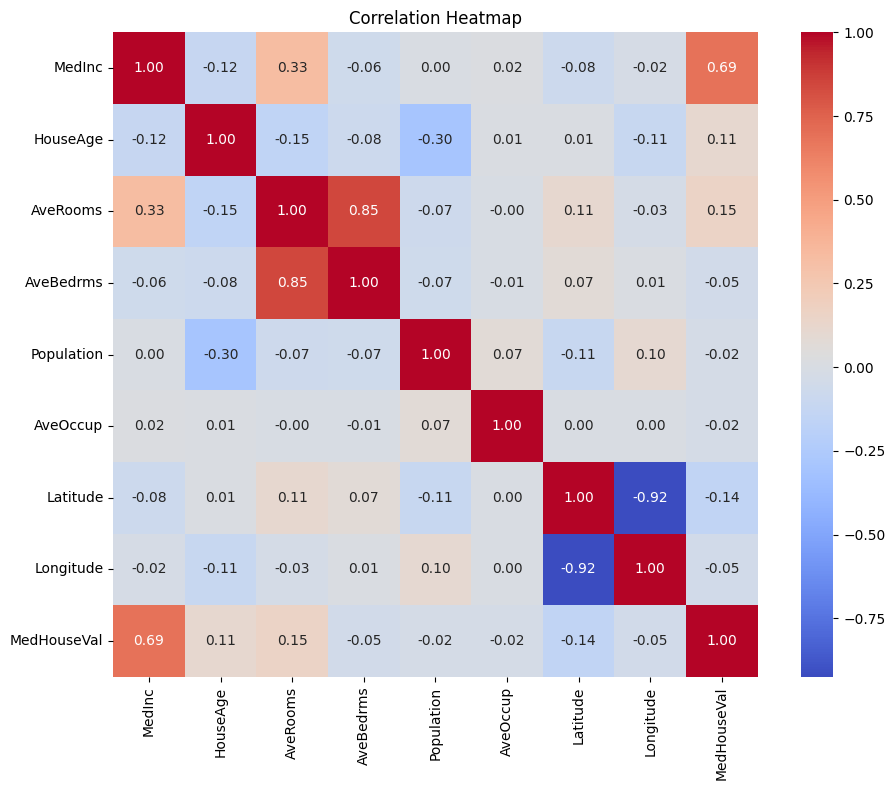

Features strongly correlated with MedHouseVal:


MedInc        0.688075
AveRooms      0.151948
Latitude      0.144160
HouseAge      0.105623
AveBedrms     0.046701
Longitude     0.045967
Population    0.024650
AveOccup      0.023737
Name: MedHouseVal, dtype: float64

Important features summary:
- MedInc often has the strongest positive relationship with house value.
- AveRooms tends to increase value, but very high room counts may show diminishing returns.
- HouseAge can have a mixed effect, where older homes may be worth less unless location and amenities compensate.


In [6]:
print("Dataset shape:", df.shape)
print()
print("Summary statistics:")
display(df.describe())

corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

strong_corr = corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False)
print("Features strongly correlated with MedHouseVal:")
display(strong_corr.head(10))

print("Important features summary:")
print("- MedInc often has the strongest positive relationship with house value.")
print("- AveRooms tends to increase value, but very high room counts may show diminishing returns.")
print("- HouseAge can have a mixed effect, where older homes may be worth less unless location and amenities compensate.")

## Train-Test Split

Split the data into training and testing sets using an 80-20 split with a fixed random state for reproducibility.

In [7]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (16512, 8) (16512,)
Test set: (4128, 8) (4128,)


## Model Training (LightGBM)

Train a LightGBM regression model with reasonable default parameters for the California Housing dataset.

In [8]:
model = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1)
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## Model Evaluation

Evaluate the trained model using RMSE and R² score on the test set.

In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))

In [11]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2 score: {r2:.4f}")

Test RMSE: 0.4440
Test R2 score: 0.8496


## SHAP Analysis

Use SHAP to explain model predictions for the test set and compute interaction values.

In [15]:
explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test)
interaction_values = shap.TreeExplainer(model).shap_interaction_values(X_test)
print("SHAP explanation generated for the test set.")

 99%|===================| 4095/4128 [01:45<00:00]        

SHAP explanation generated for the test set.


## SHAP Summary Plots

Visualize global feature importance and the overall distribution of SHAP values.

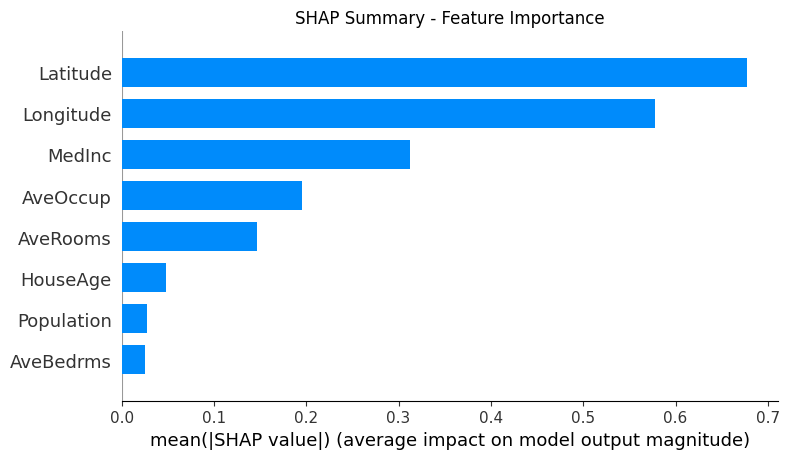

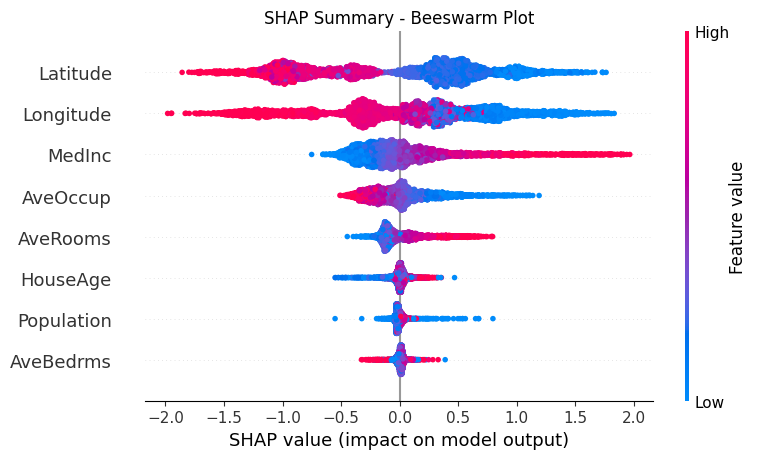

Top SHAP-important features:


Latitude      0.677375
Longitude     0.577945
MedInc        0.311946
AveOccup      0.195192
AveRooms      0.146466
HouseAge      0.047730
Population    0.027322
AveBedrms     0.025504
dtype: float64


MedInc is the most impactful feature for predicting house prices, followed by room count and location-related values.


In [16]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Summary - Feature Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary - Beeswarm Plot')
plt.tight_layout()
plt.show()

shap_mean_abs = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.Series(shap_mean_abs, index=X_test.columns).sort_values(ascending=False)
print("Top SHAP-important features:")
display(feature_importance.head(10))
print("")
print("MedInc is the most impactful feature for predicting house prices, followed by room count and location-related values.")

## SHAP Dependence Plots

Analyze non-linear effects and interactions for key features such as `MedInc`, `AveRooms`, and `HouseAge`.

<Figure size 1000x600 with 0 Axes>

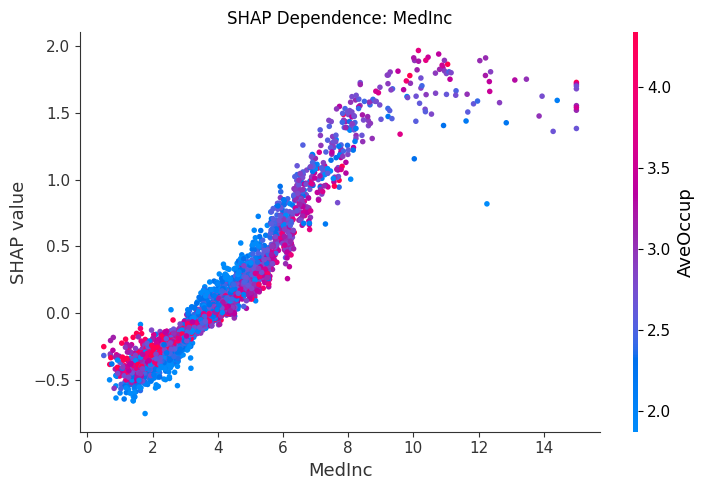

<Figure size 1000x600 with 0 Axes>

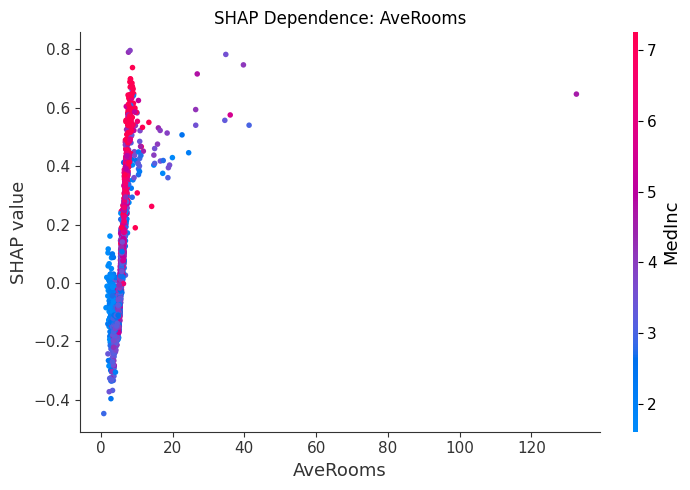

<Figure size 1000x600 with 0 Axes>

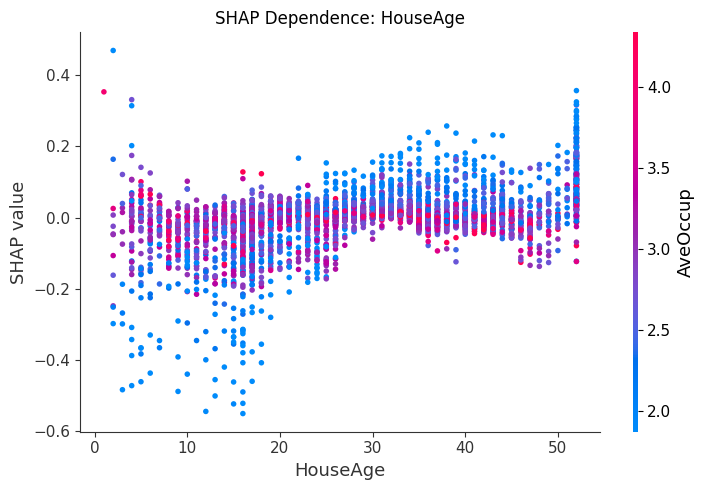

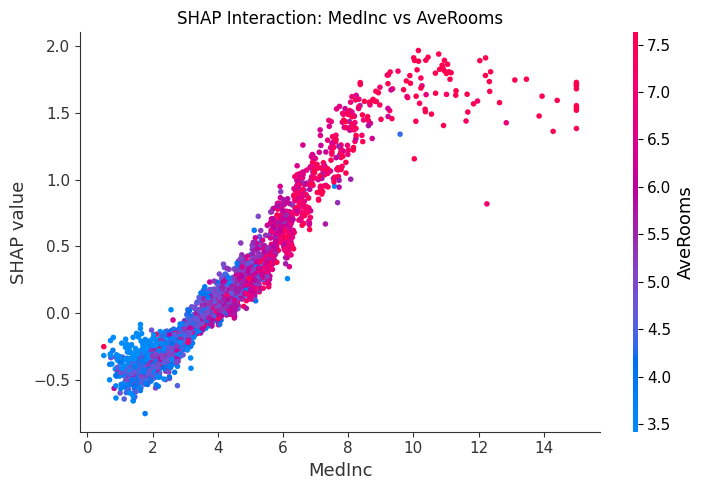

In [18]:
plt.figure(figsize=(10, 6))
shap.dependence_plot('MedInc', shap_values.values, X_test, show=False)
plt.title('SHAP Dependence: MedInc')
plt.xlabel('MedInc')
plt.ylabel('SHAP value')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot('AveRooms', shap_values.values, X_test, show=False)
plt.title('SHAP Dependence: AveRooms')
plt.xlabel('AveRooms')
plt.ylabel('SHAP value')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot('HouseAge', shap_values.values, X_test, show=False)
plt.title('SHAP Dependence: HouseAge')
plt.xlabel('HouseAge')
plt.ylabel('SHAP value')
plt.tight_layout()
plt.show()

shap.dependence_plot('MedInc', shap_values.values, X_test, interaction_index='AveRooms', show=False)
plt.title('SHAP Interaction: MedInc vs AveRooms')
plt.xlabel('MedInc')
plt.ylabel('SHAP value')
plt.tight_layout()
plt.show()

## Partial Dependence Plots

Compare SHAP results with partial dependence plots to verify how feature values affect model predictions.

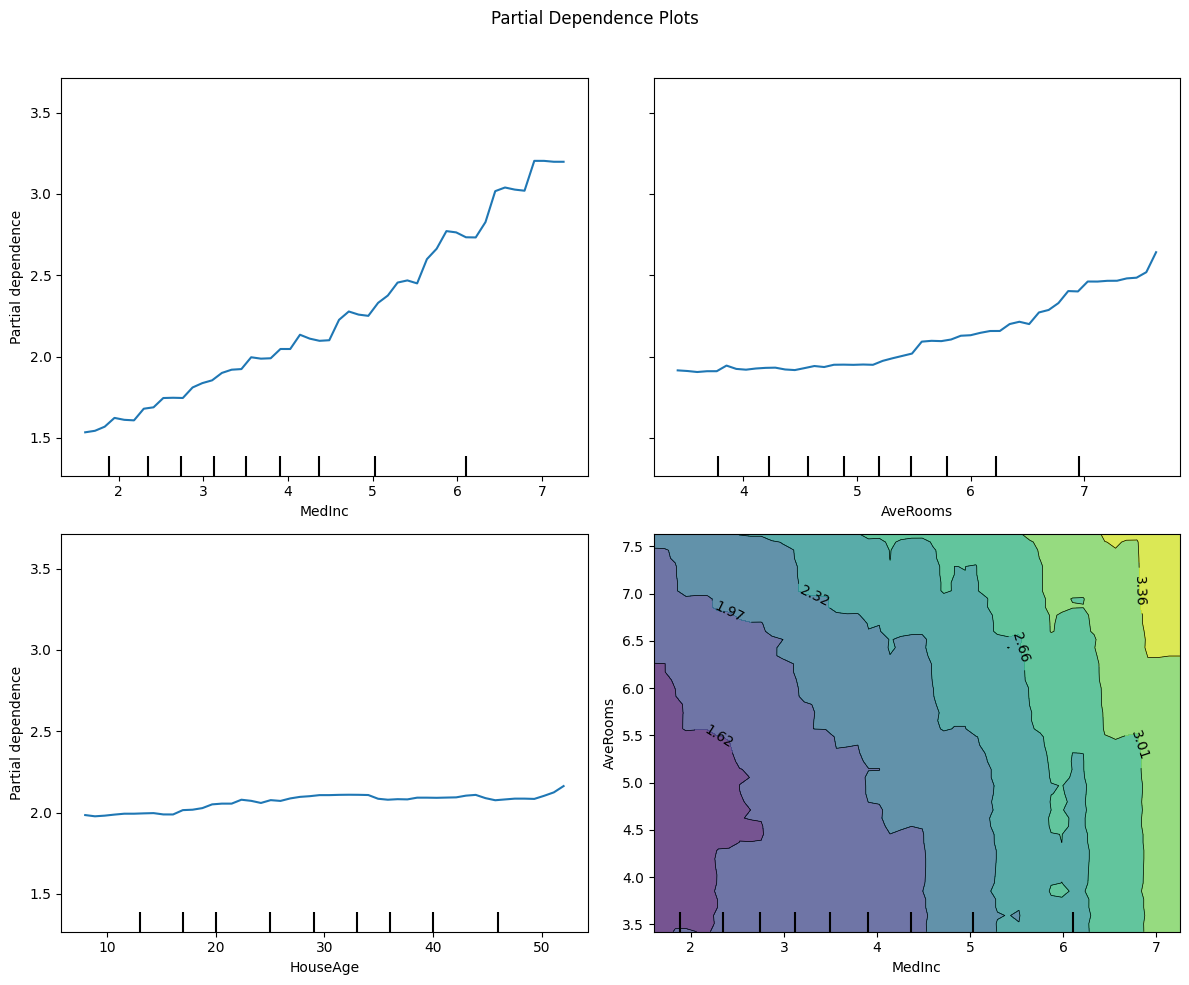

In [19]:
features = ['MedInc', 'AveRooms', 'HouseAge', ('MedInc', 'AveRooms')]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
PartialDependenceDisplay.from_estimator(model, X_test, features, kind='average', ax=axes, grid_resolution=50)
fig.suptitle('Partial Dependence Plots')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Final Insights

Summarize the main findings from the model evaluation and SHAP analysis.

- The LightGBM model shows strong predictive performance for California housing values.
- SHAP identified `MedInc` as the most important feature, with non-linear effects and saturation at high income levels.
- `AveRooms` and `HouseAge` also influence predictions in non-linear ways, consistent with diminishing returns and age-related depreciation.
- SHAP interaction plots reveal how income and room count jointly impact value, while partial dependence plots confirm the overall shape of each feature effect.
- In real-world housing prediction, non-linear relationships are important because price effects depend on thresholds, feature combinations, and changing marginal influence.